## **🚀 📘 NOTEBOOK: Pothole Detection (YOLOv8 + RDD2022)**

🧱 1. Setup Environment

In [1]:
# Install dependencies
!pip install -q ultralytics kaggle opencv-python matplotlib

# Restart runtime after this if needed

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.1 MB/s eta 0:00:00


🔐 2. Kaggle API Setup

In [2]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

📥 3. Download Dataset (RDD2022 Clean Split)

In [3]:
# Download dataset
!kaggle datasets download -d aliabdelmenam/rdd-2022

# Unzip
!unzip -q rdd-2022.zip -d data

Dataset URL: https://www.kaggle.com/datasets/aliabdelmenam/rdd-2022
License(s): CC-BY-SA-4.0
100% 9.90G/9.90G [01:25<00:00, 125MB/s]



📂 4. Verify Dataset Structure

In [4]:
import os

base_path = "/content/data/RDD_SPLIT"

for split in ["train", "val", "test"]:
    print(f"\n🔹 {split.upper()}")
    print("Images:", len(os.listdir(f"{base_path}/{split}/images")))
    print("Labels:", len(os.listdir(f"{base_path}/{split}/labels")))


🔹 TRAIN
Images: 26869
Labels: 26869

🔹 VAL
Images: 5758
Labels: 5758

🔹 TEST
Images: 5758
Labels: 5758


🔍 5. Inspect Labels (Class Mapping Check)

In [5]:
label_path = f"{base_path}/train/labels"

for file in os.listdir(label_path)[:5]:
    print(f"\n📄 {file}")
    with open(os.path.join(label_path, file)) as f:
        print(f.read())


📄 China_Drone_001102.txt
1 0.510742 0.062500 0.341797 0.058594


📄 China_MotorBike_001560.txt
2 0.461914 0.489258 0.263672 0.158203
2 0.421875 0.806641 0.324219 0.277344
0 0.441406 0.227539 0.046875 0.298828


📄 China_MotorBike_000391.txt
2 0.401367 0.586914 0.275391 0.826172
0 0.457031 0.115234 0.050781 0.109375


📄 United_States_001697.txt
1 0.300000 0.964844 0.278125 0.064062
0 0.715625 0.861719 0.256250 0.267188
0 0.539062 0.723437 0.053125 0.131250
1 0.673438 0.666406 0.128125 0.023438
0 0.818750 0.711719 0.362500 0.195312


📄 United_States_003562.txt
1 0.650781 0.821875 0.223438 0.093750
1 0.510156 0.710938 0.176563 0.037500
1 0.197656 0.703906 0.392188 0.039062



🧹 6. Filter Only Potholes (D40 → class 0)

In [6]:
for split in ["train", "val"]:
    label_dir = f"{base_path}/{split}/labels"

    for file in os.listdir(label_dir):
        file_path = os.path.join(label_dir, file)

        with open(file_path, "r") as f:
            lines = f.readlines()

        new_lines = []
        for line in lines:
            parts = line.strip().split()
            class_id = int(parts[0])

            if class_id == 3:  # pothole
                parts[0] = "0"
                new_lines.append(" ".join(parts))

        with open(file_path, "w") as f:
            f.write("\n".join(new_lines))

🧼 7. Remove Empty Labels + Images

In [7]:
for split in ["train", "val"]:
    label_dir = f"{base_path}/{split}/labels"
    image_dir = f"{base_path}/{split}/images"

    for file in os.listdir(label_dir):
        file_path = os.path.join(label_dir, file)

        if os.path.getsize(file_path) == 0:
            os.remove(file_path)

            img_file = file.replace(".txt", ".jpg")
            img_path = os.path.join(image_dir, img_file)

            if os.path.exists(img_path):
                os.remove(img_path)

📊 8. Visualize Sample Images

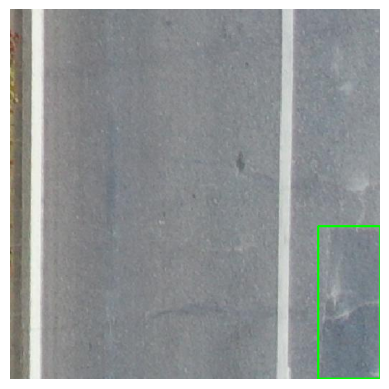

In [8]:
import cv2
import matplotlib.pyplot as plt
import random

def show_sample():
    img_dir = f"{base_path}/train/images"
    label_dir = f"{base_path}/train/labels"

    file = random.choice(os.listdir(img_dir))
    img_path = os.path.join(img_dir, file)
    label_path = os.path.join(label_dir, file.replace(".jpg", ".txt"))

    img = cv2.imread(img_path)
    h, w, _ = img.shape

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                _, x, y, bw, bh = map(float, line.split())

                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)

                cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

show_sample()

⚙️ 9. Create data.yaml

In [9]:
yaml_content = """
path: /content/data/RDD_SPLIT

train: train/images
val: val/images

names:
  0: pothole
"""

with open("data.yaml", "w") as f:
    f.write(yaml_content)

🤖 10. Train YOLO Model

In [10]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # start small

model.train(
    data="data.yaml",
    epochs=30,
    imgsz=640,
    batch=16
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, k

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b6b1046ec60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

📈 11. Evaluate Model

In [11]:
metrics = model.val()
print(metrics)

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2194.4±878.9 MB/s, size: 76.3 KB)
val: Scanning /content/data/RDD_SPLIT/val/labels.cache... 1093 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1093/1093 458.4Mit/s 0.0s
val: /content/data/RDD_SPLIT/val/images/Japan_006536.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 69/69 5.8it/s 11.9s
                   all       1093       1563      0.773      0.747      0.817      0.507
Speed: 1.5ms preprocess, 3.8ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.Confusi

📦 12. Save / Export Model

In [12]:
# Best weights path
model_path = "/content/runs/detect/train/weights/best.pt"

print("Model saved at:", model_path)

Model saved at: /content/runs/detect/train/weights/best.pt


🔄 13. Export to Different Formats (for Web/App)

In [13]:
model.export(format="onnx")
model.export(format="tflite")
model.export(format="torchscript")

Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (6.0 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 296ms
Prepared 4 packages in 3.88s
Installed 4 packages in 313ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.90

requirements: AutoUpdate success ✅ 5.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.90...
ONNX: export success ✅ 6.6s, saved as '/content/runs/

PosixPath('/content/runs/detect/train/weights/best.torchscript')

🌐 14. Minimal Inference Function (Web Ready)

In [14]:
def detect_potholes(image_path):
    results = model(image_path)
    return results[0].plot()

🧪 15. SANITY CHECK (Upload Image & Test)

Saving China_Drone_000083.jpg to China_Drone_000083 (5).jpg

image 1/1 /content/China_Drone_000083 (5).jpg: 640x640 1 pothole, 34.2ms
Speed: 16.4ms preprocess, 34.2ms inference, 2.2ms postprocess per image at shape (1, 3, 640, 640)


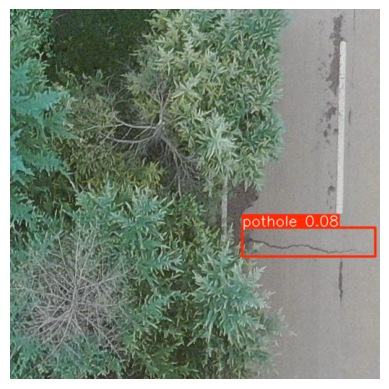

In [35]:
from google.colab import files
from PIL import Image

uploaded = files.upload()

for file in uploaded.keys():
    result = model(file,conf=0.05)

    img = result[0].plot()
    plt.imshow(img)
    plt.axis("off")

In [36]:
import shutil
import os

output_zip_path = 'yolov8n_pothole_model_exports.zip'
model_exports_dir = '/content/runs/detect/train/weights'

# Create a zip archive of the model exports directory
shutil.make_archive(os.path.splitext(output_zip_path)[0], 'zip', model_exports_dir)

print(f"All model files (best.pt, onnx, tflite, torchscript) have been zipped to: {output_zip_path}")

All model files (best.pt, onnx, tflite, torchscript) have been zipped to: yolov8n_pothole_model_exports.zip


In [37]:
from google.colab import files

# Offer the zip file for download
files.download(output_zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>